Using device: cuda
BasicCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=1152, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

MODEL SUMMARY

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 28, 28]             320
              ReLU-2           [-1, 32, 28, 28]               0
         MaxPool2d-3           [-1, 32, 14, 14]               0
            Conv2d-4           [-1, 64, 14, 14]          18,496
              ReLU-5           [-1, 64, 14, 14]               0
   

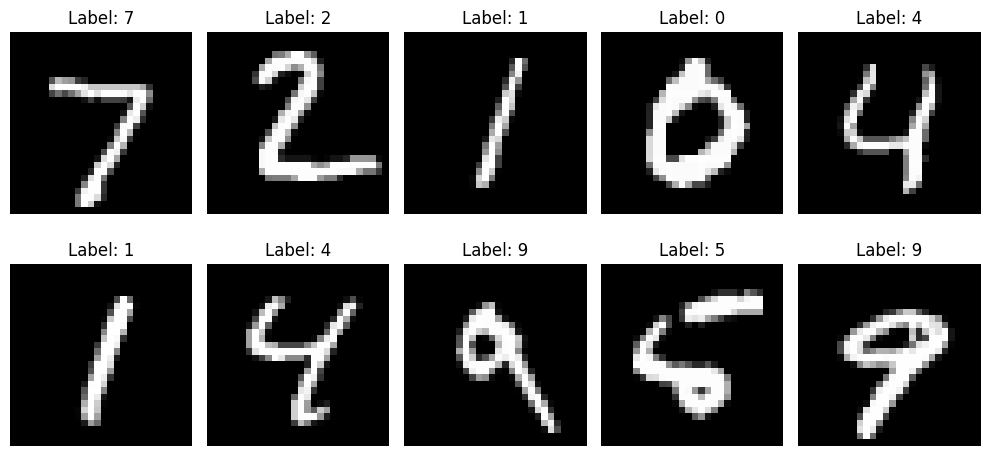

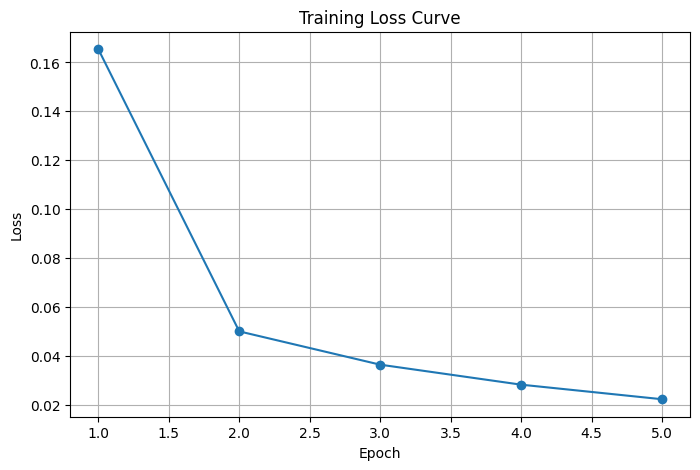

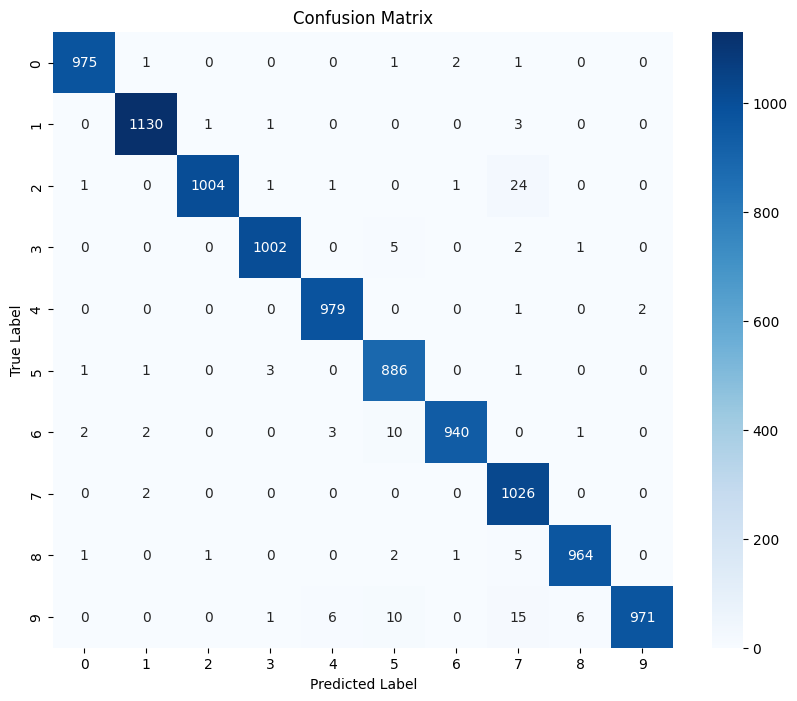

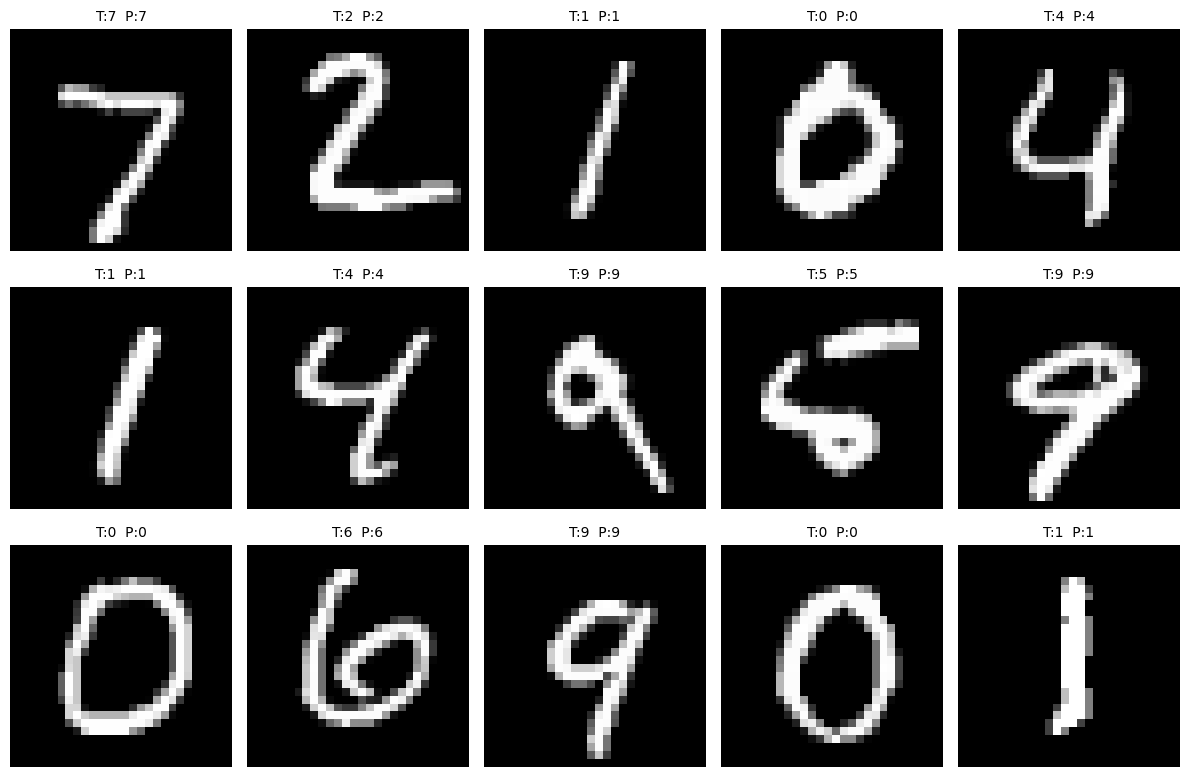

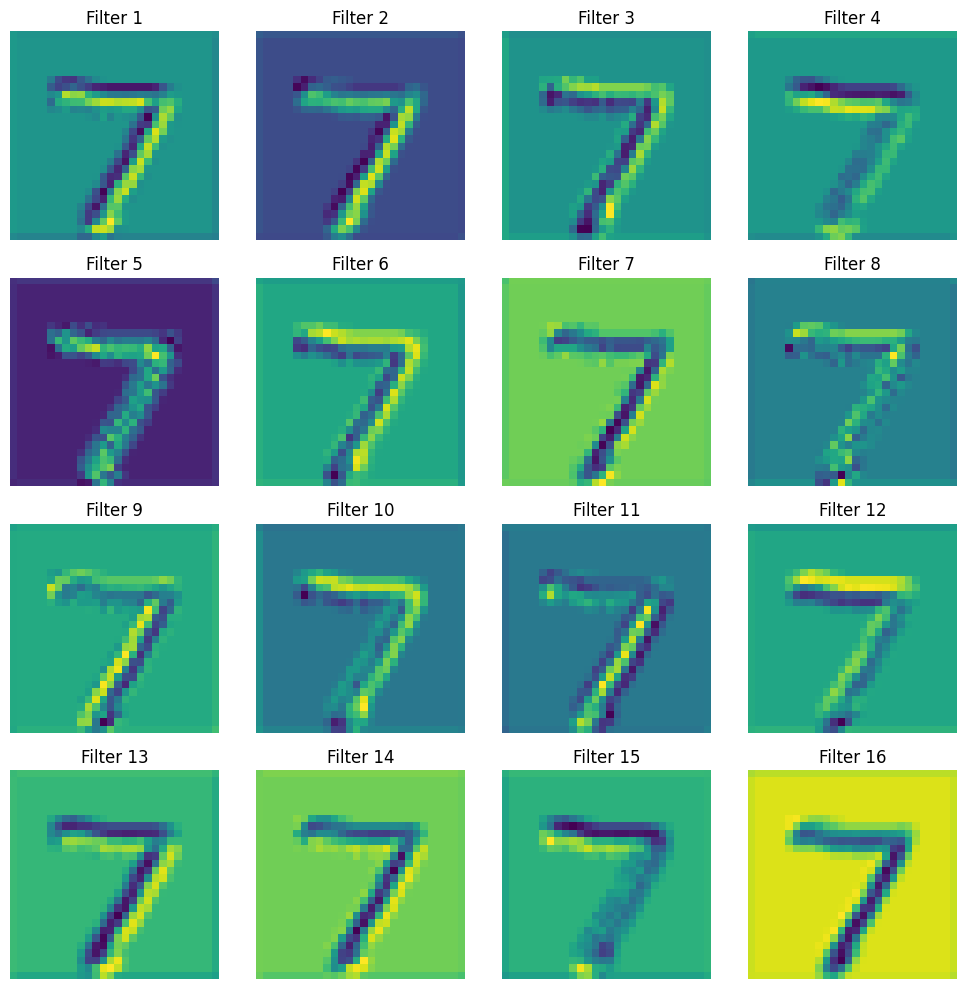

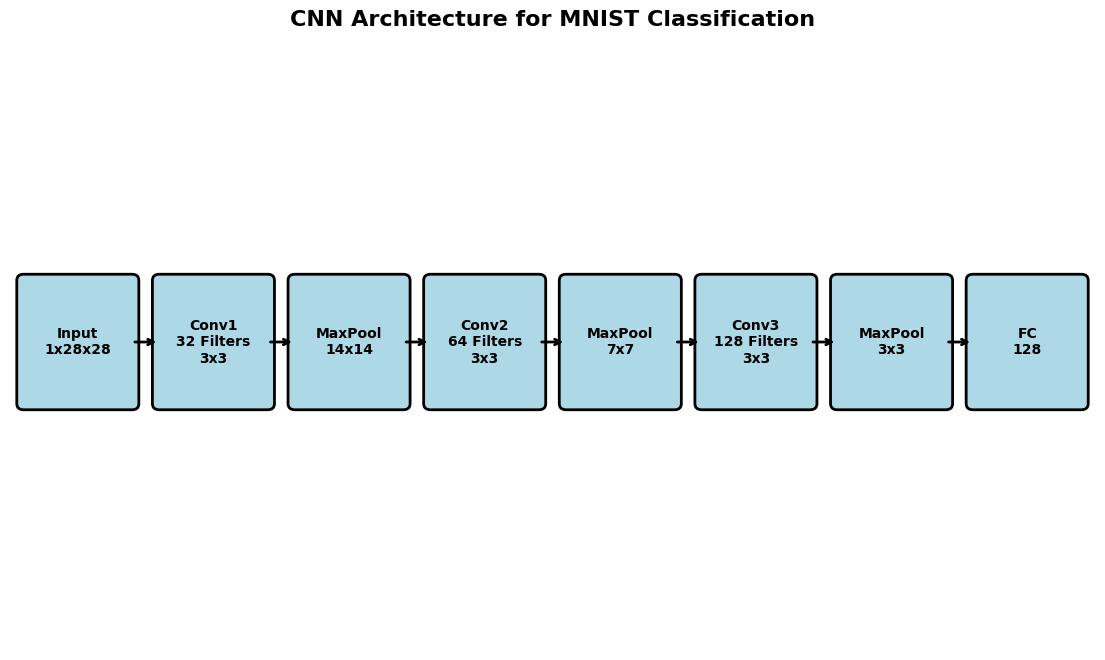

CNN architecture image saved successfully.


In [6]:
# ============================================================
# BASIC CNN FOR MNIST + VISUALIZATION + ARCHITECTURE DIAGRAM
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms

from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import confusion_matrix
import seaborn as sns

from torchsummary import summary

# OPTIONAL (for architecture image)
# pip install torchviz
from torchviz import make_dot


# ============================================================
# DEVICE
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)


# ============================================================
# HYPERPARAMETERS
# ============================================================

BATCH_SIZE = 64
LEARNING_RATE = 0.001
EPOCHS = 5


# ============================================================
# TRANSFORMS
# ============================================================

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])


# ============================================================
# DATASET
# ============================================================

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


# ============================================================
# CNN MODEL
# ============================================================

class BasicCNN(nn.Module):

    def __init__(self):
        super(BasicCNN, self).__init__()

        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)

        self.relu = nn.ReLU()

        self.pool = nn.MaxPool2d(2, 2)

        self.dropout = nn.Dropout(0.25)

        self.fc1 = nn.Linear(128 * 3 * 3, 128)

        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):

        x = self.pool(self.relu(self.conv1(x)))

        x = self.pool(self.relu(self.conv2(x)))

        x = self.pool(self.relu(self.conv3(x)))

        x = x.view(x.size(0), -1)

        x = self.relu(self.fc1(x))

        x = self.dropout(x)

        x = self.fc2(x)

        return x


model = BasicCNN().to(device)

print(model)


# ============================================================
# MODEL SUMMARY
# ============================================================

print("\nMODEL SUMMARY\n")

summary(model, (1, 28, 28))


# ============================================================
# LOSS + OPTIMIZER
# ============================================================

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)


# ============================================================
# TRAINING
# ============================================================

train_losses = []

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    train_losses.append(epoch_loss)

    print(f"Epoch [{epoch+1}/{EPOCHS}] Loss: {epoch_loss:.4f}")


# ============================================================
# EVALUATION
# ============================================================

model.eval()

correct = 0
total = 0

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = 100 * correct / total

print(f"\nTest Accuracy: {accuracy:.2f}%")


# ============================================================
# VISUALIZATION 1
# SAMPLE MNIST IMAGES
# ============================================================

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

images, labels = next(iter(test_loader))

for i, ax in enumerate(axes.flat):

    img = images[i].squeeze().numpy()

    ax.imshow(img, cmap='gray')

    ax.set_title(f"Label: {labels[i].item()}")

    ax.axis('off')

plt.tight_layout()

plt.savefig("mnist_samples.png", dpi=300)

plt.show()


# ============================================================
# VISUALIZATION 2
# TRAINING LOSS CURVE
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(range(1, EPOCHS + 1), train_losses, marker='o')

plt.title("Training Loss Curve")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid(True)

plt.savefig("training_loss_curve.png", dpi=300)

plt.show()


# ============================================================
# VISUALIZATION 3
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.savefig("confusion_matrix.png", dpi=300)

plt.show()


# ============================================================
# VISUALIZATION 4
# PREDICTION RESULTS
# ============================================================

fig, axes = plt.subplots(3, 5, figsize=(12, 8))

images, labels = next(iter(test_loader))

images = images.to(device)

outputs = model(images)

_, predicted = torch.max(outputs, 1)

images = images.cpu()

for i, ax in enumerate(axes.flat):

    img = images[i].squeeze().numpy()

    ax.imshow(img, cmap='gray')

    ax.set_title(
        f"T:{labels[i].item()}  P:{predicted[i].item()}",
        fontsize=10
    )

    ax.axis('off')

plt.tight_layout()

plt.savefig("prediction_results.png", dpi=300)

plt.show()


# ============================================================
# VISUALIZATION 5
# FEATURE MAPS FROM FIRST CONVOLUTION LAYER
# ============================================================

sample_image = images[0].unsqueeze(0).to(device)

with torch.no_grad():

    feature_maps = model.conv1(sample_image)

feature_maps = feature_maps.cpu()

fig, axes = plt.subplots(4, 4, figsize=(10, 10))

for i, ax in enumerate(axes.flat):

    ax.imshow(feature_maps[0, i].numpy(), cmap='viridis')

    ax.axis('off')

    ax.set_title(f"Filter {i+1}")

plt.tight_layout()

plt.savefig("feature_maps.png", dpi=300)

plt.show()


# ============================================================
# MODEL ARCHITECTURE IMAGE
# ============================================================

# ============================================================
# MODEL ARCHITECTURE VISUALIZATION (MATPLOTLIB VERSION)
# ============================================================

import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(14, 8))

ax.set_xlim(0, 16)
ax.set_ylim(0, 10)

ax.axis('off')

layers = [
    ("Input\n1x28x28", 1),
    ("Conv1\n32 Filters\n3x3", 3),
    ("MaxPool\n14x14", 5),
    ("Conv2\n64 Filters\n3x3", 7),
    ("MaxPool\n7x7", 9),
    ("Conv3\n128 Filters\n3x3", 11),
    ("MaxPool\n3x3", 13),
    ("FC\n128", 15),
]

for text, x in layers:

    rect = patches.FancyBboxPatch(
        (x-0.8, 4),
        1.6,
        2,
        boxstyle="round,pad=0.1",
        edgecolor='black',
        linewidth=2,
        facecolor='lightblue'
    )

    ax.add_patch(rect)

    ax.text(
        x,
        5,
        text,
        ha='center',
        va='center',
        fontsize=10,
        fontweight='bold'
    )

# Draw arrows
for i in range(len(layers)-1):

    x1 = layers[i][1] + 0.8
    x2 = layers[i+1][1] - 0.8

    ax.annotate(
        "",
        xy=(x2, 5),
        xytext=(x1, 5),
        arrowprops=dict(arrowstyle="->", lw=2)
    )

plt.title(
    "CNN Architecture for MNIST Classification",
    fontsize=16,
    fontweight='bold'
)

plt.savefig(
    "cnn_model_architecture.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("CNN architecture image saved successfully.")